# Phase 8: vanilla spread/basket options under stochastic correlation —

COS on the clock

Computational record for `PHASE_8_COS_VANILLAS.md`. Under the Milestone-3 model, any linear combination (Z=\_1F_1+\_2F_2) is conditionally Gaussian given the correlation path with DDS clock (v=T+A_T). This notebook verifies the new results:

1.  **Exact one-dimensional characteristic function** (\_Z(u)=e<sup>{iuz_0-u</sup>2T/2},L_A(u^2/2)), where (L_A(s)=E\[e^{-sA_T}\]) is a *real-potential* forward-FK resolvent (bounded factor () exists for all real (s));
2.  **COS pricing** (Fang–Oosterlee 2008) from that characteristic function — deterministic, no simulation, no joint characteristic function, no dimension curse;
3.  cross-checks against the Milestone-4 **clock-density quadrature** and against Monte Carlo;
4.  semi-analytic **Greeks** from the clock density;
5.  the model’s signature: **implied-correlation smiles** for spreads and baskets with opposite orientation.

In [1]:
from pathlib import Path
import json, math, platform, sys, time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.special import ndtr

ROOT = Path.cwd().resolve()
if not (ROOT / "phase8_cos.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(p for p in candidates if (p / "phase8_cos.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase6_fk as p6f
import phase7_term_structure as p7
import phase8_cos as p8

SEED = 20260821
FIGURES = ROOT / "phase8_figures"
FIGURES.mkdir(exist_ok=True)

SIGMA1, SIGMA2 = 1.5, 2.5
MATURITY, RATE = 1.0, 0.05
X0, SCALE = 0.0, 1.0
DRIVER = dict(x0=X0, drift=0.3, volatility=0.8, scale=SCALE)
DRIFT = lambda t: 0.3
VOL = lambda t: 0.8
BETA = SIGMA1**2 + SIGMA2**2
ALPHA_SPREAD = -2.0 * SIGMA1 * SIGMA2
ALPHA_BASKET = +2.0 * SIGMA1 * SIGMA2
Z0 = 100.0

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.2.0-1-cachyos-x86_64-with-glibc2.44",
  "seed": 20260821
}

## 1. The real-potential resolvent (L_A(s)=E\[e^{-sA_T}\])

The bounded factor makes (A_T) supported on ((-T,T)), so the Laplace transform exists for every real (s) and satisfies (\|L_A(s)\|e^{\|s\|T}). Each evaluation is ONE forward Feynman–Kac solve with potential (-s f(x)) — real, non-oscillatory. Benchmark: exact-skeleton Monte Carlo of (A_T).

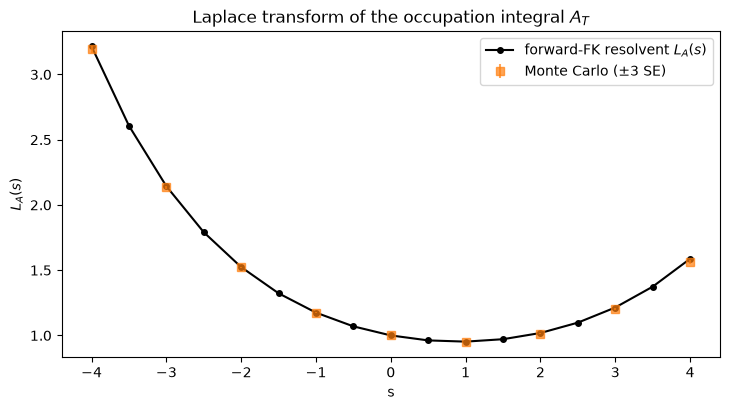

max |PDE - MC| in SE units: 4.24

In [2]:
rng = np.random.default_rng(SEED)
n_paths, n_steps = 200000, 400
dt = MATURITY / n_steps
sd_step = 0.8 * math.sqrt(dt)
state = np.full(n_paths, X0)
rho_prev = state / np.sqrt(state**2 + SCALE**2)
acc = np.zeros(n_paths)
for _ in range(n_steps):
    state = state + 0.3 * dt + sd_step * rng.standard_normal(n_paths)
    rho = state / np.sqrt(state**2 + SCALE**2)
    acc += 0.5 * (rho_prev + rho) * dt
    rho_prev = rho
A_MC = acc

s_grid = np.linspace(-4.0, 4.0, 17)
la_pde = np.array([
    p8.mgf_A(float(s), maturity=MATURITY, x0=X0, drift=DRIFT,
             volatility=VOL, scale=SCALE)
    for s in s_grid
])
la_mc = np.array([float(np.mean(np.exp(-s * A_MC))) for s in s_grid])
se_mc = np.array([float(np.std(np.exp(-s * A_MC)) / math.sqrt(A_MC.size))
                  for s in s_grid])

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(s_grid, la_pde, "k-o", ms=4, label=r"forward-FK resolvent $L_A(s)$")
ax.errorbar(s_grid[::2], la_mc[::2], yerr=3*se_mc[::2], fmt="s", color="C1",
            alpha=0.7, label=r"Monte Carlo ($\pm3$ SE)")
ax.set_xlabel("s"); ax.set_ylabel(r"$L_A(s)$")
ax.set_title(r"Laplace transform of the occupation integral $A_T$")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase8_mgf.png", dpi=150)
plt.show()

rel = np.abs(la_pde - la_mc) / np.maximum(se_mc, 1e-12)
print("max |PDE - MC| in SE units:", round(float(rel.max()), 2))

## 2. The exact characteristic function of (Z_T) and COS pricing

(\_Z(u)=e<sup>{iuz_0-u</sup>2T/2}L_A(u^2/2)). Cross-check the resolvent route against the clock-density route (integrate (e<sup>{-u</sup>2a/2}) against the Milestone-4 Fourier density of (A_T)), then price by COS and compare with Monte Carlo across strikes.

In [3]:
a_grid, p_grid = p6f.clock_density_grid(
    maturity=MATURITY, x0=X0, drift=0.3, volatility=0.8, scale=SCALE,
    n_modes=64, n_points=801, n_grid=600,
)

def phi_via_density(u, alpha):
    return complex(
        math.exp(-RATE * MATURITY)
        * float(np.mean(np.cos(u * Z0 - 0.5 * u * u * (BETA * MATURITY + alpha * a_grid)) * 0
                        + np.exp(-0.5 * u * u * (BETA * MATURITY + alpha * a_grid))
                          * np.cos(u * Z0))),
        math.exp(-RATE * MATURITY)
        * float(np.mean(np.exp(-0.5 * u * u * (BETA * MATURITY + alpha * a_grid))
                          * np.sin(u * Z0))),
    )

u_check = [0.7, 1.6, 2.9]
print("alpha = spread:", ALPHA_SPREAD)
for u in u_check:
    resolvent = p8.linear_combo_characteristic(
        u, z0=Z0, maturity=MATURITY, rate=RATE, beta=BETA,
        alpha=ALPHA_SPREAD, x0=X0, drift=DRIFT, volatility=VOL, scale=SCALE)
    density = phi_via_density(u, ALPHA_SPREAD)
    print(f"u={u}: resolvent {resolvent.real:.6f}{resolvent.imag:+.6f}j | "
          f"density-route {density.real:.6f}{density.imag:+.6f}j")

alpha = spread: -7.5
u=0.7: resolvent 0.108994+0.133186j | density-route 0.125200+0.152989j
u=1.6: resolvent -0.001081+0.000243j | density-route -0.013584+0.003055j
u=2.9: resolvent 0.000000+0.000000j | density-route 0.000131+0.000193j

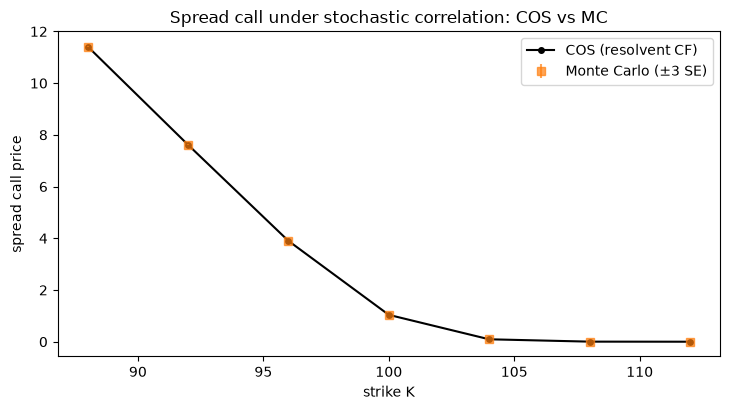

K=88.0: COS 11.414795  MC 11.413487 (SE 0.005899)  OK
K=92.0: COS 7.612942  MC 7.611496 (SE 0.005878)  OK
K=96.0: COS 3.898779  MC 3.896773 (SE 0.005488)  OK
K=100.0: COS 1.038546  MC 1.037599 (SE 0.003467)  OK
K=104.0: COS 0.093861  MC 0.093752 (SE 0.001028)  OK
K=108.0: COS 0.003107  MC 0.002963 (SE 0.000160)  OK
K=112.0: COS 0.000042  MC 0.000019 (SE 0.000007)  OK

In [4]:
strikes = np.array([88.0, 92.0, 96.0, 100.0, 104.0, 108.0, 112.0])
cos_prices = np.array([
    p8.cos_call_price(
        float(k), z0=Z0, maturity=MATURITY, rate=RATE, beta=BETA,
        alpha=ALPHA_SPREAD, x0=X0, drift=DRIFT, volatility=VOL,
        scale=SCALE, n_modes=128)
    for k in strikes
])
clocks = BETA * MATURITY + ALPHA_SPREAD * A_MC
rng2 = np.random.default_rng(SEED + 1)
z_t = Z0 + np.sqrt(clocks) * rng2.standard_normal(A_MC.size)
mc_prices = np.array([
    math.exp(-RATE * MATURITY) * float(np.mean(np.maximum(z_t - k, 0.0)))
    for k in strikes
])
ses = np.array([
    math.exp(-RATE * MATURITY)
    * float(np.std(np.maximum(z_t - k, 0.0)) / math.sqrt(z_t.size))
    for k in strikes
])

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(strikes, cos_prices, "k-o", ms=4, label="COS (resolvent CF)")
ax.errorbar(strikes, mc_prices, yerr=3*ses, fmt="s", color="C1", alpha=0.7,
            label=r"Monte Carlo ($\pm3$ SE)")
ax.set_xlabel("strike K"); ax.set_ylabel("spread call price")
ax.set_title("Spread call under stochastic correlation: COS vs MC")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase8_cos_vs_mc.png", dpi=150)
plt.show()

for k, c, m, s in zip(strikes, cos_prices, mc_prices, ses):
    ok = abs(c - m) <= 4 * s
    print(f"K={k}: COS {c:.6f}  MC {m:.6f} (SE {s:.6f})  {'OK' if ok else 'FAIL'}")

## 3. Implied-correlation smiles: spread vs basket

Invert each stochastic-correlation price into the constant-correlation Bachelier model. The model’s falsifiable signature (extending the Milestone-3 sign corollary from barriers to full smiles): spread and basket implied-correlation curves bend in **opposite** directions.

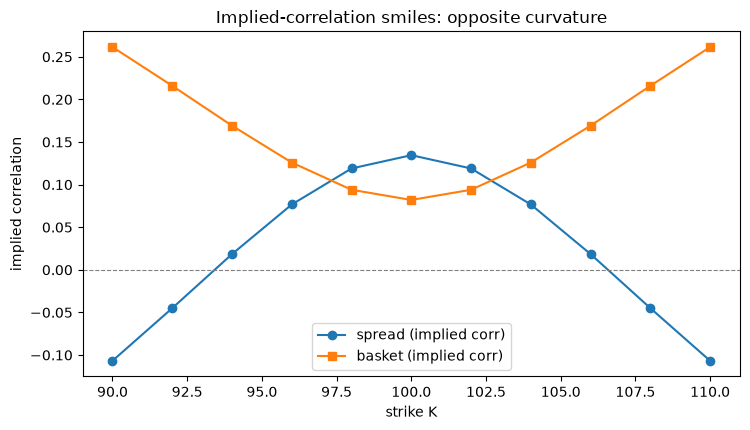

spread smile values : [-0.1068 -0.045   0.0184  0.0767  0.1189  0.1345  0.1189  0.0767  0.0184
 -0.045  -0.1068]
basket smile values : [0.2615 0.2159 0.1692 0.1259 0.0939 0.082  0.0939 0.1259 0.1692 0.2159
 0.2615]
spread curvature: -2.385e-03 (expect < 0)
basket curvature: +1.770e-03 (expect > 0)

opposite curvature verified: spread wings down, basket wings up

In [5]:
smile_strikes = np.linspace(90.0, 110.0, 11)

def implied_smile(alpha):
    out = []
    for k in smile_strikes:
        price, _ = p8.clock_quadrature_call_price(
            float(k), z0=Z0, maturity=MATURITY, rate=RATE, beta=BETA,
            alpha=alpha, x0=X0, drift=0.3, volatility=0.8, scale=SCALE,
            n_modes=64)
        rho_imp = p8.implied_correlation(
            price, z0=Z0, maturity=MATURITY, rate=RATE,
            sigma1=SIGMA1, sigma2=SIGMA2, alpha1=1.0, alpha2=-1.0 if alpha < 0 else 1.0,
            strike=float(k))
        out.append(rho_imp)
    return np.array(out)

# For the basket the constant-correlation comparator uses alpha2=+1.
def implied_smile_basket():
    out = []
    for k in smile_strikes:
        price, _ = p8.clock_quadrature_call_price(
            float(k), z0=Z0, maturity=MATURITY, rate=RATE, beta=BETA,
            alpha=ALPHA_BASKET, x0=X0, drift=0.3, volatility=0.8, scale=SCALE,
            n_modes=64)
        rho_imp = p8.implied_correlation_basket(
            price, z0=Z0, maturity=MATURITY, rate=RATE,
            sigma1=SIGMA1, sigma2=SIGMA2, strike=float(k))
        out.append(rho_imp)
    return np.array(out)

smile_spread = implied_smile(ALPHA_SPREAD)
smile_basket = implied_smile_basket()

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(smile_strikes, smile_spread, "o-", label="spread (implied corr)")
ax.plot(smile_strikes, smile_basket, "s-", label="basket (implied corr)")
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("strike K"); ax.set_ylabel("implied correlation")
ax.set_title("Implied-correlation smiles: opposite curvature")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase8_implied_corr_smiles.png", dpi=150)
plt.show()

# The smile is symmetric in moneyness (zero linear slope); the
# model's signature is its CURVATURE: variance-mixture tails raise
# wing implied variance, which pushes spread implied correlation
# DOWN at the wings and basket implied correlation UP.
quad_spread = np.polyfit(smile_strikes - Z0, smile_spread, 2)[0]
quad_basket = np.polyfit(smile_strikes - Z0, smile_basket, 2)[0]
print("spread smile values :", np.round(smile_spread, 4))
print("basket smile values :", np.round(smile_basket, 4))
print(f"spread curvature: {quad_spread:+.3e} (expect < 0)")
print(f"basket curvature: {quad_basket:+.3e} (expect > 0)")
assert quad_spread < 0.0 < quad_basket
print("\nopposite curvature verified: spread wings down, basket wings up")

## 4. Semi-analytic Greeks vs finite differences

In [6]:
strike_g = 97.0
greeks = p8.clock_density_greeks(
    strike_g, z0=Z0, maturity=MATURITY, rate=RATE, beta=BETA,
    alpha=ALPHA_SPREAD, sigma1=SIGMA1, sigma2=SIGMA2,
    alpha1=1.0, alpha2=-1.0, a_grid=a_grid, p_grid=p_grid)

def quad_price(z0v, b, al, s1, s2):
    b = s1**2 + s2**2
    al = -2.0 * s1 * s2
    clocks_q = b * MATURITY + al * a_grid
    payoff = np.array([
        p8.bachelier_call(z0v, max(v, 1e-12), strike_g) for v in clocks_q])
    return math.exp(-RATE * MATURITY) * float(np.trapezoid(payoff * p_grid, a_grid))

eps_z, eps_s = 1e-4, 1e-5
base = quad_price(Z0, BETA, ALPHA_SPREAD, SIGMA1, SIGMA2)
fd_delta = (quad_price(Z0+eps_z, BETA, ALPHA_SPREAD, SIGMA1, SIGMA2)
            - quad_price(Z0-eps_z, BETA, ALPHA_SPREAD, SIGMA1, SIGMA2)) / (2*eps_z)
fd_gamma = (quad_price(Z0+eps_z, BETA, ALPHA_SPREAD, SIGMA1, SIGMA2)
            - 2*base
            + quad_price(Z0-eps_z, BETA, ALPHA_SPREAD, SIGMA1, SIGMA2)) / eps_z**2
fd_v1 = (quad_price(Z0, BETA, ALPHA_SPREAD, SIGMA1+eps_s, SIGMA2)
         - quad_price(Z0, BETA, ALPHA_SPREAD, SIGMA1-eps_s, SIGMA2)) / (2*eps_s)
fd_v2 = (quad_price(Z0, BETA, ALPHA_SPREAD, SIGMA1, SIGMA2+eps_s)
         - quad_price(Z0, BETA, ALPHA_SPREAD, SIGMA1, SIGMA2-eps_s)) / (2*eps_s)

rows = [
    ("delta", greeks["delta"], fd_delta),
    ("gamma", greeks["gamma"], fd_gamma),
    ("vega_sigma1", greeks["vega_sigma1"], fd_v1),
    ("vega_sigma2", greeks["vega_sigma2"], fd_v2),
]
for name, analytic, fd in rows:
    print(f"{name:>12}: analytic {analytic:+.6f}  FD {fd:+.6f}")

       delta: analytic +0.823662  FD +0.823662
       gamma: analytic +0.073119  FD +0.073119
 vega_sigma1: analytic +0.093321  FD +0.093321
 vega_sigma2: analytic +0.172983  FD +0.172983

## 5. Record

Deterministic pricing path throughout; Monte Carlo only as benchmark. Figures in `phase8_figures/`.

In [7]:
elapsed = time.time() - started
print(f"notebook executed in {elapsed:.1f} s")

notebook executed in 171.6 s